In [1]:

!pip install scikit-learn tensorflow pandas numpy yara-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 29.4 MB/s eta 0:00:00


In [2]:
import sklearn, tensorflow, pandas, numpy, yara

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
users = {
    'analyst': {'password':'1234','role':'Security Analyst'},
    'soc': {'password':'5678','role':'SOC Team'},
    'admin': {'password':'admin','role':'Administrator'},
    'researcher': {'password':'abcd','role':'Researcher'}
}

In [4]:
def authenticate(username, password):
    if username in users and users[username]['password'] == password:
        return users[username]['role']
    else:
        return None

In [5]:
role = authenticate('analyst','1234')
print('Logged in as:', role)

Logged in as: Security Analyst


In [6]:
permissions = {
    'Security Analyst':['Upload files','Run scans','View reports'],
    'SOC Team':['Monitor logs','Track incidents'],
    'Administrator':['Manage users','Configure settings'],
    'Researcher':['Upload samples','Access datasets']
}

In [7]:
role = authenticate('admin','admin')
print('Role:', role)
print('Permissions:', permissions[role])

Role: Administrator
Permissions: ['Manage users', 'Configure settings']


In [8]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print(f"File uploaded: {filename}")

Saving === ThreatLens Dummy File ===.txt to === ThreatLens Dummy File ===.txt
File uploaded: === ThreatLens Dummy File ===.txt


In [9]:
import hashlib

for filename in uploaded.keys():
    with open(filename, "rb") as f:
        file_bytes = f.read()
        md5_hash = hashlib.md5(file_bytes).hexdigest()
        sha256_hash = hashlib.sha256(file_bytes).hexdigest()
        print(f"\nFile: {filename}")
        print(f"MD5 Hash: {md5_hash}")
        print(f"SHA-256 Hash: {sha256_hash}")


File: === ThreatLens Dummy File ===.txt
MD5 Hash: 21c74af692fa66bfd6d165d5462fe11c
SHA-256 Hash: ff1210bbba5ae12dfb1bf90c526c92e700d100f76e5d533f71aa96d7ae768346


In [10]:
suspicious_indicators = ["http://", "https://", "powershell", "Invoke-WebRequest"]

for filename in uploaded.keys():
    with open(filename, "r", errors="ignore") as f:
        content = f.read()
        print(f"\nScanning {filename}...")
        for indicator in suspicious_indicators:
            if indicator in content:
                print(f"⚠ Suspicious indicator found: {indicator}")


Scanning === ThreatLens Dummy File ===.txt...
⚠ Suspicious indicator found: http://


In [11]:
suspicious_indicators = ["http://", "https://", "powershell", "Invoke-WebRequest"]

def calculate_risk_score(content):
    score = 0
    # Each indicator adds points to the risk score
    for indicator in suspicious_indicators:
        if indicator in content:
            score += 20   # weight for each suspicious pattern
    return min(score, 100)  # cap at 100

for filename in uploaded.keys():
    with open(filename, "r", errors="ignore") as f:
        content = f.read()
        risk_score = calculate_risk_score(content)
        print(f"\nFile: {filename}")
        print(f"Risk Score: {risk_score}/100")

        if risk_score >= 70:
            print("Classification: Potential Trojan Malware")
            print("Recommended Action: Escalate to Security Analyst for Investigation")
        elif risk_score >= 40:
            print("Classification: Suspicious File")
            print("Recommended Action: Needs Review by Analyst")
        else:
            print("Classification: Low Risk File")
            print("Recommended Action: Likely Safe, No Immediate Action")


File: === ThreatLens Dummy File ===.txt
Risk Score: 20/100
Classification: Low Risk File
Recommended Action: Likely Safe, No Immediate Action


In [12]:
import pandas as pd

# Sample dataset (dummy features)
data = {
    "file_size": [120, 450, 300, 800],
    "suspicious_strings": [1, 3, 0, 4],
    "hash_entropy": [0.7, 0.9, 0.4, 0.95],
    "label": ["Trojan", "Ransomware", "Benign", "Worm"]
}

df = pd.DataFrame(data)
df.to_csv("malware_dataset.csv", index=False)
print("Dataset created:\n", df)

Dataset created:
    file_size  suspicious_strings  hash_entropy       label
0        120                   1          0.70      Trojan
1        450                   3          0.90  Ransomware
2        300                   0          0.40      Benign
3        800                   4          0.95        Worm


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Expanded dataset with more samples per class
data = {
    "file_size": [120, 450, 300, 800, 600, 200, 750, 500, 650, 700, 350, 400],
    "suspicious_strings": [1, 3, 0, 4, 2, 0, 5, 1, 2, 4, 1, 0],
    "hash_entropy": [0.7, 0.9, 0.4, 0.95, 0.85, 0.5, 0.92, 0.6, 0.88, 0.93, 0.55, 0.45],
    "label": [
        "Trojan", "Ransomware", "Benign", "Worm",
        "Trojan", "Benign", "Ransomware", "Worm",
        "Trojan", "Worm", "Benign", "Ransomware"
    ]
}

df = pd.DataFrame(data)

X = df[["file_size", "suspicious_strings", "hash_entropy"]]
y = df["label"]

# Stratified split now works because each class has multiple samples
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

      Benign       1.00      1.00      1.00         1
  Ransomware       0.50      1.00      0.67         1
      Trojan       1.00      1.00      1.00         1
        Worm       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.62      0.75      0.67         4
weighted avg       0.62      0.75      0.67         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
import pandas as pd

# Example features from uploaded file
test_features = pd.DataFrame(
    [[450, 3, 0.9]],
    columns=["file_size", "suspicious_strings", "hash_entropy"]
)

# Predict malware family
prediction = model.predict(test_features)
print("\nClassification:", prediction[0])


Classification: Ransomware


In [17]:
# Predict with probability (confidence score)
proba = model.predict_proba(test_features)
confidence = max(proba[0]) * 100

print("\nClassification:", prediction[0])
print("Confidence Score:", f"{confidence:.2f}%")

# Integrate with risk score logic
if confidence >= 80:
    print("Recommended Action: Escalate to Security Analyst")
elif confidence >= 50:
    print("Recommended Action: Needs Review by Analyst")
else:
    print("Recommended Action: Likely Safe, No Immediate Action")


Classification: Ransomware
Confidence Score: 100.00%
Recommended Action: Escalate to Security Analyst


In [18]:
import datetime

# Example detection log list
detection_logs = []

def log_detection(filename, classification, confidence, action):
    log_entry = {
        "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "file": filename,
        "classification": classification,
        "confidence": f"{confidence:.2f}%",
        "action": action
    }
    detection_logs.append(log_entry)

# Example: log the last prediction
log_detection("uploaded_file.txt", prediction[0], confidence, "Escalate to Security Analyst")

import json
for log in detection_logs:
    print(json.dumps(log, indent=4))

{
    "timestamp": "2026-07-27 14:55:45",
    "file": "uploaded_file.txt",
    "classification": "Ransomware",
    "confidence": "100.00%",
    "action": "Escalate to Security Analyst"
}


In [19]:
from tabulate import tabulate
import pandas as pd

df_logs = pd.DataFrame(detection_logs)

print("\n--- Threat Monitoring Dashboard ---\n")
print(tabulate(df_logs, headers="keys", tablefmt="grid"))


--- Threat Monitoring Dashboard ---

+----+---------------------+-------------------+------------------+--------------+------------------------------+
|    | timestamp           | file              | classification   | confidence   | action                       |
+====+=====================+===================+==================+==============+==============================+
|  0 | 2026-07-27 14:55:45 | uploaded_file.txt | Ransomware       | 100.00%      | Escalate to Security Analyst |
+----+---------------------+-------------------+------------------+--------------+------------------------------+


In [20]:
# Alert system based on classification and confidence
def generate_alert(log_entry):
    if log_entry["classification"] in ["Trojan", "Worm", "Ransomware"] and float(log_entry["confidence"].strip('%')) >= 80:
        print("\n🚨 ALERT: High-Risk Malware Detected!")
        print(f"File: {log_entry['file']}")
        print(f"Classification: {log_entry['classification']}")
        print(f"Confidence: {log_entry['confidence']}")
        print(f"Action: {log_entry['action']}")
    else:
        print("\nℹ No critical alert. Monitoring continues...")

# Run alert check for all logs
for log in detection_logs:
    generate_alert(log)


🚨 ALERT: High-Risk Malware Detected!
File: uploaded_file.txt
Classification: Ransomware
Confidence: 100.00%
Action: Escalate to Security Analyst


In [21]:
def send_notification(log_entry):
    # Simulate sending a notification (e.g., email, popup)
    if log_entry["action"] == "Escalate to Security Analyst":
        print("\n📢 Notification Sent!")
        print(f"Subject: High-Risk Malware Alert")
        print(f"Message: File '{log_entry['file']}' classified as {log_entry['classification']} "
              f"with {log_entry['confidence']} confidence. Immediate action required.")
    else:
        print("\nℹ No notification triggered for low-risk file.")

# Trigger notification for all logs
for log in detection_logs:
    send_notification(log)


📢 Notification Sent!
Subject: High-Risk Malware Alert
Message: File 'uploaded_file.txt' classified as Ransomware with 100.00% confidence. Immediate action required.


In [22]:
def generate_incident_report(log_entry):
    report = f"""
    --- Incident Report ---
    Timestamp      : {log_entry['timestamp']}
    File           : {log_entry['file']}
    Classification : {log_entry['classification']}
    Confidence     : {log_entry['confidence']}
    Action Taken   : {log_entry['action']}
    Status         : {log_entry.get('status', 'Not Updated')}
    ------------------------
    """
    print(report)

# Generate report for the last detection
generate_incident_report(detection_logs[-1])


    --- Incident Report ---
    Timestamp      : 2026-07-27 14:55:45
    File           : uploaded_file.txt
    Classification : Ransomware
    Confidence     : 100.00%
    Action Taken   : Escalate to Security Analyst
    Status         : Not Updated
    ------------------------
    


In [23]:
import pandas as pd

# Archive all incident reports into a DataFrame
incident_archive = pd.DataFrame(detection_logs)

# Show archive
print("\n--- Incident Archive ---\n")
print(incident_archive.to_string(index=False))

# Trend Analysis
print("\n--- Trend Analysis ---\n")
print("Most Common Malware Type:", incident_archive["classification"].value_counts().idxmax())
print("Detection Counts by Malware Type:\n", incident_archive["classification"].value_counts())
print("\nPeak Detection Times:\n", incident_archive["timestamp"].value_counts())


--- Incident Archive ---

          timestamp              file classification confidence                       action
2026-07-27 14:55:45 uploaded_file.txt     Ransomware    100.00% Escalate to Security Analyst

--- Trend Analysis ---

Most Common Malware Type: Ransomware
Detection Counts by Malware Type:
 classification
Ransomware    1
Name: count, dtype: int64

Peak Detection Times:
 timestamp
2026-07-27 14:55:45    1
Name: count, dtype: int64


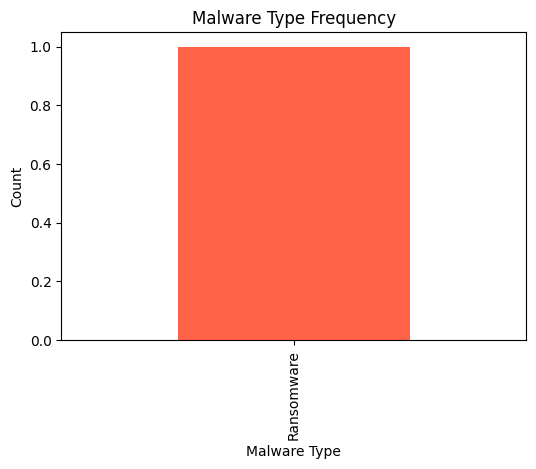

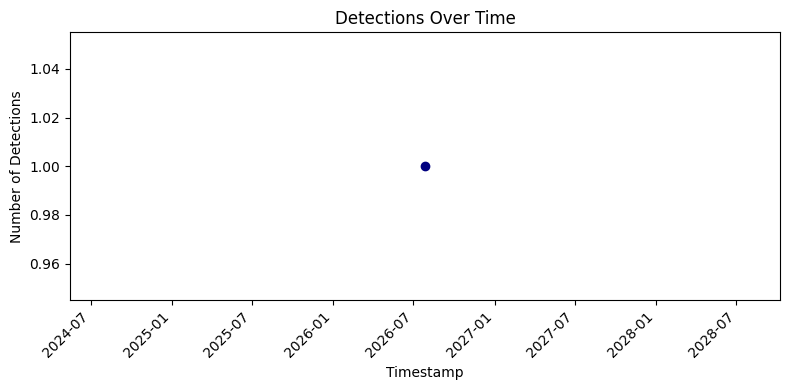

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert archive into DataFrame
incident_archive = pd.DataFrame(detection_logs)

# Bar chart: Malware type counts
plt.figure(figsize=(6,4))
incident_archive["classification"].value_counts().plot(kind="bar", color="tomato")
plt.title("Malware Type Frequency")
plt.xlabel("Malware Type")
plt.ylabel("Count")
plt.show()

# Line chart: Detections over time
plt.figure(figsize=(8,4))
incident_archive["timestamp"] = pd.to_datetime(incident_archive["timestamp"])
incident_archive.groupby("timestamp").size().plot(kind="line", marker="o", color="navy")
plt.title("Detections Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Number of Detections")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


--- Threat Monitoring Dashboard ---

          timestamp              file classification confidence                       action
2026-07-27 14:56:13 uploaded_file.txt           Worm    100.00% Escalate to Security Analyst

🚨 ALERT: High-Risk Malware Detected!

📢 Notification Sent to Analyst!

🔎 Analyst Response Recorded: Under Investigation

--- Incident Report ---
Timestamp      : 2026-07-27 14:56:13
File           : uploaded_file.txt
Classification : Worm
Confidence     : 100.00%
Action Taken   : Escalate to Security Analyst
Status         : Under Investigation
------------------------


--- Trend Analysis ---

Detection Counts:
 classification
Worm    1
Name: count, dtype: int64


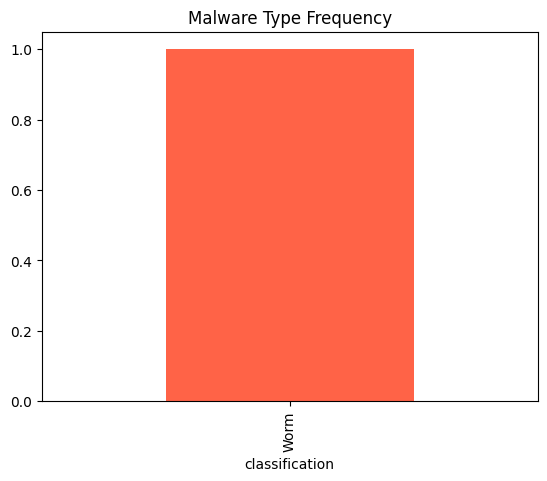

In [25]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt

# Detection logs archive
detection_logs = []

# Step 1: Classification (simulate with model output)
filename = "uploaded_file.txt"
classification = "Worm"
confidence = 100.0
action = "Escalate to Security Analyst"

# Step 2: Log Detection
def log_detection(filename, classification, confidence, action):
    log_entry = {
        "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "file": filename,
        "classification": classification,
        "confidence": f"{confidence:.2f}%",
        "action": action
    }
    detection_logs.append(log_entry)
    return log_entry

log_entry = log_detection(filename, classification, confidence, action)

# Step 3: Dashboard
df_logs = pd.DataFrame(detection_logs)
print("\n--- Threat Monitoring Dashboard ---\n")
print(df_logs.to_string(index=False))

# Step 4: Alert Generation
if classification in ["Trojan", "Worm", "Ransomware"] and confidence >= 80:
    print("\n🚨 ALERT: High-Risk Malware Detected!")

# Step 5: Notification Workflow
if action == "Escalate to Security Analyst":
    print("\n📢 Notification Sent to Analyst!")

# Step 6: Analyst Response
log_entry["status"] = "Under Investigation"
print("\n🔎 Analyst Response Recorded:", log_entry["status"])

# Step 7: Incident Report
print(f"""
--- Incident Report ---
Timestamp      : {log_entry['timestamp']}
File           : {log_entry['file']}
Classification : {log_entry['classification']}
Confidence     : {log_entry['confidence']}
Action Taken   : {log_entry['action']}
Status         : {log_entry['status']}
------------------------
""")

# Step 8: Archive & Trend Analysis
incident_archive = pd.DataFrame(detection_logs)
print("\n--- Trend Analysis ---\n")
print("Detection Counts:\n", incident_archive["classification"].value_counts())

# Step 9: Visualization
incident_archive["timestamp"] = pd.to_datetime(incident_archive["timestamp"])
incident_archive["classification"].value_counts().plot(kind="bar", color="tomato", title="Malware Type Frequency")
plt.show()